In [5]:
import geopandas as gpd
import pandas as pd

geo = gpd.read_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Geology\bedrock_merged.shp")

geo.to_crs(epsg=27700, inplace=True)

Unclassified features remaining: 0


<Axes: >

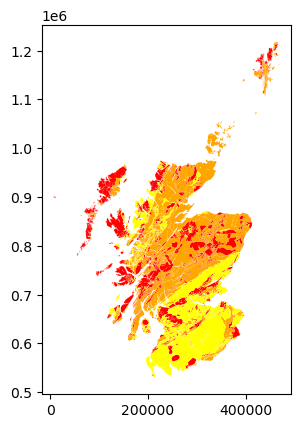

In [2]:


# Define updated bedrock classification categories
hard_bedrock = [
    "ANORTHOSITE", "DOLERITE AND THOLEIITIC BASALT", "FELSIC LAVA AND FELSIC TUFF",
    "FELSIC-ROCK", "GNEISS", "MAFIC GNEISS", "MAFIC IGNEOUS-ROCK", "MAFIC LAVA AND MAFIC TUFF",
    "MAFITE", "QUARTZITE", "SYENITIC-ROCK", "ULTRAMAFITITE",
    "LAVA, TUFF, VOLCANICLASTIC ROCK AND SEDIMENTARY ROCK", "GNEISSOSE PSAMMITE AND GNEISSOSE SEMIPELITE"
]

medium_bedrock = [
    "BRECCIA, CONGLOMERATE AND SANDSTONE", "CONGLOMERATE AND [SUBEQUAL/SUBORDINATE] SANDSTONE, INTERBEDDED",
    "CONGLOMERATE, SANDSTONE, SILTSTONE AND MUDSTONE", "GNEISSOSE SEMIPELITE AND GNEISSOSE PSAMMITE",
    "GRAPHITIC PELITE, CALCAREOUS PELITE, CALCSILICATE-ROCK AND PSAMMITE", "LIMESTONE, ARGILLACEOUS ROCKS AND SUBORDINATE SANDSTONE, INTERBEDDED",
    "METALIMESTONE", "METASEDIMENTARY ROCK", "MIGMATITIC ROCK", "MYLONITIC-ROCK AND FAULT-BRECCIA",
    "PSAMMITE", "PSAMMITE AND PELITE", "PSAMMITE, PELITE, SEMIPELITE AND CALCSILICATE-ROCK",
    "PSAMMITE, SEMIPELITE AND PELITE", "PYROCLASTIC-ROCK", "QUARTZ-ARENITE",
    "SANDSTONE AND CONGLOMERATE, INTERBEDDED", "SANDSTONE, MUDSTONE, SILTSTONE AND CONGLOMERATE",
    "SCHIST", "SERPENTINITE, METABASALT, METALIMESTONE AND PSAMMITE",
    "SANDSTONE WITH SUBORDINATE ARGILLACEOUS ROCKS AND LIMESTONE", "PSAMMITE AND SEMIPELITE"
]

soft_bedrock = [
    "DIAMICTITE", "DOLOSTONE", "GRAVEL, SAND, SILT AND CLAY",
    "LIMESTONE WITH SUBORDINATE SANDSTONE AND ARGILLACEOUS ROCKS", "MUDSTONE, CHERT AND SMECTITE-CLAYSTONE",
    "MUDSTONE, SANDSTONE AND CONGLOMERATE", "MUDSTONE, SANDSTONE AND LIMESTONE",
    "MUDSTONE, SILTSTONE AND SANDSTONE", "MUDSTONE, SILTSTONE, LIMESTONE AND SANDSTONE",
    "MUDSTONE, SILTSTONE, SANDSTONE, COAL, IRONSTONE AND FERRICRETE",
    "SEDIMENTARY ROCK CYCLES, CLACKMANNAN GROUP TYPE", "SEDIMENTARY ROCK CYCLES, STRATHCLYDE GROUP TYPE",
    "SEMIPELITE", "SEMIPELITE AND PELITE", "SANDSTONE AND MUDSTONE",
    "SANDSTONE WITH SUBORDINATE ARGILLACEOUS ROCKS", "SANDSTONE WITH SUBORDINATE CONGLOMERATE AND SILTSTONE",
    "SANDSTONE WITH SUBORDINATE CONGLOMERATE, SILTSTONE AND MUDSTONE",
    "SANDSTONE, BRECCIA AND CONGLOMERATE", "SANDSTONE, SILTSTONE AND MUDSTONE", "WACKE",
    "LIMESTONE, SANDSTONE, SILTSTONE AND MUDSTONE", "PELITE"
]

# Create separate GeoDataFrames using 'geo' as the main dataset, filtering by RCS_D column
gdf_hard = geo[geo["RCS_D"].isin(hard_bedrock)]
gdf_medium = geo[geo["RCS_D"].isin(medium_bedrock)]
gdf_soft = geo[geo["RCS_D"].isin(soft_bedrock)]

# Identify and retain any unclassified features
gdf_unclassified = geo[~geo["RCS_D"].isin(hard_bedrock + medium_bedrock + soft_bedrock)]
print(f"Unclassified features remaining: {len(gdf_unclassified)}")

# Print any remaining unclassified rock types for verification
if not gdf_unclassified.empty:
    print(gdf_unclassified[["RCS_D"]])

# Save to shapefiles for verification
#gdf_hard.to_file("hard_bedrock.shp")
#gdf_medium.to_file("medium_bedrock.shp")
#gdf_soft.to_file("soft_bedrock.shp")
#if not gdf_unclassified.empty:
#    gdf_unclassified.to_file("unclassified_bedrock.shp")

ax= gdf_hard.plot(color='red', label='Hard Bedrock')
gdf_medium.plot(ax=ax, color='orange', label='Medium Bedrock')
gdf_soft.plot(ax=ax, color='yellow', label='Soft Bedrock')



In [7]:
igneous_bedrock = [
    "ANORTHOSITE", "DOLERITE AND THOLEIITIC BASALT", "FELSIC LAVA AND FELSIC TUFF",
    "FELSIC-ROCK", "MAFIC IGNEOUS-ROCK", "MAFIC LAVA AND MAFIC TUFF", "MAFITE",
    "SYENITIC-ROCK", "ULTRAMAFITITE", "PYROCLASTIC-ROCK",
    "LAVA, TUFF, VOLCANICLASTIC ROCK AND SEDIMENTARY ROCK"  # Mixed classification, but predominantly igneous
]

metamorphic_bedrock = [
    "GNEISS", "MAFIC GNEISS", "GNEISSOSE PSAMMITE AND GNEISSOSE SEMIPELITE",
    "GNEISSOSE SEMIPELITE AND GNEISSOSE PSAMMITE", "GRAPHITIC PELITE, CALCAREOUS PELITE, CALCSILICATE-ROCK AND PSAMMITE",
    "METALIMESTONE", "METASEDIMENTARY ROCK", "MIGMATITIC ROCK", "MYLONITIC-ROCK AND FAULT-BRECCIA",
    "SCHIST", "SERPENTINITE, METABASALT, METALIMESTONE AND PSAMMITE",
    "SEMIPELITE", "SEMIPELITE AND PELITE",
    "PSAMMITE", "PSAMMITE AND PELITE", "PSAMMITE AND SEMIPELITE", 
    "PSAMMITE, PELITE, SEMIPELITE AND CALCSILICATE-ROCK", "PSAMMITE, SEMIPELITE AND PELITE", "QUARTZITE"
]

sedimentary_bedrock = [
    "BRECCIA, CONGLOMERATE AND SANDSTONE", "CONGLOMERATE AND [SUBEQUAL/SUBORDINATE] SANDSTONE, INTERBEDDED",
    "CONGLOMERATE, SANDSTONE, SILTSTONE AND MUDSTONE", "LIMESTONE, ARGILLACEOUS ROCKS AND SUBORDINATE SANDSTONE, INTERBEDDED",
    "SANDSTONE AND CONGLOMERATE, INTERBEDDED", "SANDSTONE, MUDSTONE, SILTSTONE AND CONGLOMERATE",
    "QUARTZ-ARENITE", "MUDSTONE, SILTSTONE AND SANDSTONE", "MUDSTONE, CHERT AND SMECTITE-CLAYSTONE",
    "MUDSTONE, SANDSTONE AND LIMESTONE", "MUDSTONE, SILTSTONE, LIMESTONE AND SANDSTONE",
    "SANDSTONE, SILTSTONE AND MUDSTONE", "SANDSTONE WITH SUBORDINATE ARGILLACEOUS ROCKS",
    "SANDSTONE, BRECCIA AND CONGLOMERATE", "WACKE", "LIMESTONE, SANDSTONE, SILTSTONE AND MUDSTONE", "PELITE",
    "DOLOSTONE", "DIAMICTITE", "SEDIMENTARY ROCK CYCLES, CLACKMANNAN GROUP TYPE", "SEDIMENTARY ROCK CYCLES, STRATHCLYDE GROUP TYPE",
    "MUDSTONE, SANDSTONE AND CONGLOMERATE", "MUDSTONE, SILTSTONE, SANDSTONE, COAL, IRONSTONE AND FERRICRETE",
    "SANDSTONE WITH SUBORDINATE ARGILLACEOUS ROCKS AND LIMESTONE", "SANDSTONE WITH SUBORDINATE CONGLOMERATE AND SILTSTONE",
    "SANDSTONE WITH SUBORDINATE CONGLOMERATE, SILTSTONE AND MUDSTONE", "GRAVEL, SAND, SILT AND CLAY", "LIMESTONE WITH SUBORDINATE SANDSTONE AND ARGILLACEOUS ROCKS",
    "SANDSTONE AND MUDSTONE"
]

# Create separate GeoDataFrames using 'geo' as the main dataset, filtering by RCS_D column
gdf_igneous = geo[geo["RCS_D"].isin(igneous_bedrock)]
gdf_metamorphic = geo[geo["RCS_D"].isin(metamorphic_bedrock)]
gdf_sedimentary = geo[geo["RCS_D"].isin(sedimentary_bedrock)]

gdf_igneous = gdf_igneous.dissolve()
gdf_metamorphic = gdf_metamorphic.dissolve()
gdf_sedimentary = gdf_sedimentary.dissolve()

# Save to shapefiles for verification
gdf_igneous.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Geology\igneous_bedrock.shp")
gdf_metamorphic.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Geology\metamorphic_bedrock.shp")
gdf_sedimentary.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Scotland\vectors\Geology\sedimentary_bedrock.shp")

gdf_unclassified = geo[~geo["RCS_D"].isin(list(gdf_igneous["RCS_D"]) + list(gdf_metamorphic["RCS_D"]) + list(gdf_sedimentary["RCS_D"]))]

print(f"Unclassified features remaining: {len(gdf_unclassified)}")




Unclassified features remaining: 55


<Axes: >

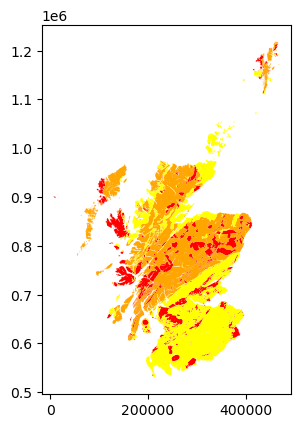

In [4]:
ax= gdf_igneous.plot(color='red', label='Hard Bedrock')
gdf_metamorphic.plot(ax=ax, color='orange', label='Medium Bedrock')
gdf_sedimentary.plot(ax=ax, color='yellow', label='Soft Bedrock')

In [8]:
import geopandas as gpd
import pandas as pd

greo = gpd.read_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Geology\G500_version_2024_Qgis\bedrock_merged.shp")

greo.drop(columns=['Descriptio', 'gm_label', 'gm_user_de', 'Shape_Leng', 'Shape_Area'], inplace=True)

greo.to_crs(epsg=3413, inplace=True)

In [ ]:
# Ensure full column width for debugging
pd.set_option("display.max_colwidth", None)

print(greo["Header"])

In [9]:
# Define classification keywords
igneous_terms = ["basalt", "syenite", "gabbro", "granite", "lava", "tuff", "nepheline", "volcanic", "dolerite", "ultramafic", "intrusive suite", "hydrothermally altered", "pillow breccias",
    "hyloclastites", "North Atlantic Igneous Province", "carbonatite", "diorite", "monzonite", "granodiorite", "quartz diorite",
    "sill", "dyke", "intrusive", "Igdlerfigssalik", "dunite", "trachyte", "effusive", "Gardar Province", "granitoid", "post-migmatitic"]
metamorphic_terms = ["gneiss", "schist", "quartzite", "migmatite", "mylonite", "amphibolite", "Supergroup", "undivided", "tectonically interleaved", "Proterozoic metamorphism", "marble", "metasedimentary", "foliated", "metagranitoid",
    "quartzofeldspathic", "greenstones", "migmatitic", "metasediments", "siliceous", "tectonised"
]
sedimentary_terms = ["sandstone", "mudstone", "limestone", "siltstone", "conglomerate", "shale", "clastic", "basin", "shelf", "deltaic deposits", "intercratonic sediments", "continental sediments", "glaciofluvial", "marine deposits", "moraine", "colluvium", "unconsolidated sand",
    "Kap København Formation", "greywacke", "marine silt", "dolomites", "Store Koldewey Formation", "Slottet Formation"
]

# Merge description and header for better classification
greo["combined_text"] = greo["Long_descr"].fillna("") + " " + greo["Header"].fillna("")

# Classify formations
gdf_igneous = greo[greo["combined_text"].str.contains('|'.join(igneous_terms), case=False, na=False)]
gdf_metamorphic = greo[greo["combined_text"].str.contains('|'.join(metamorphic_terms), case=False, na=False)]
gdf_sedimentary = greo[greo["combined_text"].str.contains('|'.join(sedimentary_terms), case=False, na=False)]

# Identify unclassified formations
gdf_unclassified = greo[~greo.index.isin(gdf_igneous.index) & ~greo.index.isin(gdf_metamorphic.index) & ~greo.index.isin(gdf_sedimentary.index)]

# Display results
print(f"Igneous formations: {len(gdf_igneous)}")
print(f"Metamorphic formations: {len(gdf_metamorphic)}")
print(f"Sedimentary formations: {len(gdf_sedimentary)}")
print(f"Unclassified formations remaining: {len(gdf_unclassified)}")

gdf_igneous = gdf_igneous.drop(columns=['Long_descr', 'Header', 'combined_text']).copy()
gdf_metamorphic = gdf_metamorphic.drop(columns=['Long_descr', 'Header', 'combined_text']).copy()
gdf_sedimentary = gdf_sedimentary.drop(columns=['Long_descr', 'Header', 'combined_text']).copy()

gdf_igneous = gdf_igneous.dissolve()
gdf_metamorphic = gdf_metamorphic.dissolve()
gdf_sedimentary = gdf_sedimentary.dissolve()

# Optional: Save classified outputs
gdf_igneous.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Geology\G500_version_2024_Qgis\igneous_formations.shp")
gdf_metamorphic.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Geology\G500_version_2024_Qgis\metamorphic_formations.shp")
gdf_sedimentary.to_file(r"D:\OneDrive - Loughborough University\Project\Spatial\Data\Greenland\Geology\G500_version_2024_Qgis\sedimentary_formations.shp")
#gdf_unclassified.to_file("unclassified_formations.shp")

Igneous formations: 193
Metamorphic formations: 157
Sedimentary formations: 202
Unclassified formations remaining: 9


In [ ]:
gdf_metamorphic


In [ ]:
from collections import Counter

all_text = " ".join(gdf_unclassified["combined_text"].dropna())
common_terms = Counter(all_text.split()).most_common(30)  # Adjust count as needed
print(common_terms)